# Student Placement & Salary Prediction — Data Understanding & EDA

This notebook covers dataset loading, initial data understanding, and exploratory
data analysis (EDA) for the Student Placement & Salary Prediction System.

**Note on the dataset:** No public dataset combines all the features this project
needs (CGPA, IQ, academic percentages, internships, projects, skills, communication,
backlogs, work experience, certifications, branch) together with both a placement
label and a salary figure. This dataset is therefore **synthetic**, generated by
`src/generate_data.py` with realistic, documented statistical relationships (not
random noise) — see that file's docstring for full details. This is stated
explicitly here and in the README.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv('../data/placement_data.csv')
df.shape

(3015, 15)

In [3]:
df.head()

,cgpa,iq_score,tenth_percentage,twelfth_percentage,graduation_percentage,internships,projects,technical_skills_score,communication_score,backlogs,certifications,work_experience_months,branch,placement_status,package_lpa
0,7.64,103,82.99,85.51,71.55,2,0,4.82,7.79,0,0,0,ECE,Not Placed,NaN
1,6.24,87,77.74,75.62,75.83,1,6,6.17,6.24,0,1,0,CSE,Placed,5.88
2,6.61,112,72.40,67.40,61.51,1,1,8.54,9.85,0,0,0,IT,Not Placed,NaN
3,5.86,95,75.02,81.45,70.33,0,4,5.03,6.63,0,2,0,ECE,Placed,4.22
4,8.20,102,91.60,73.04,69.24,1,4,4.12,7.74,1,0,3,CSE,Placed,7.33


## 3. Data Understanding

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3015 entries, 0 to 3014
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cgpa                    3015 non-null   float64
 1   iq_score                3015 non-null   int64  
 2   tenth_percentage        3015 non-null   float64
 3   twelfth_percentage      2985 non-null   float64
 4   graduation_percentage   3015 non-null   float64
 5   internships             3015 non-null   int64  
 6   projects                3015 non-null   int64  
 7   technical_skills_score  3015 non-null   float64
 8   communication_score     2955 non-null   float64
 9   backlogs                3015 non-null   int64  
 10  certifications          3015 non-null   int64  
 11  work_experience_months  3015 non-null   int64  
 12  branch                  3015 non-null   str    
 13  placement_status        3015 non-null   str    
 14  package_lpa             1493 non-null   float64
dty

In [5]:
df.describe()

,cgpa,iq_score,tenth_percentage,twelfth_percentage,graduation_percentage,internships,projects,technical_skills_score,communication_score,backlogs,certifications,work_experience_months,package_lpa
count,3015.000000,3015.000000,3015.000000,2985.000000,3015.000000,3015.000000,3015.000000,3015.000000,2955.000000,3015.000000,3015.000000,3015.000000,1493.000000
mean,6.974080,100.289552,77.916226,74.706198,71.980896,1.234163,2.488226,5.987692,6.189059,0.524710,0.994693,0.887894,6.852847
std,1.104507,14.642230,9.919490,10.018635,8.004068,1.102973,1.596210,1.956951,1.780537,0.713857,0.997328,3.139962,1.662461
min,4.000000,70.000000,42.710000,42.370000,40.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000
25%,6.240000,90.000000,71.480000,67.990000,66.605000,0.000000,1.000000,4.660000,4.990000,0.000000,0.000000,0.000000,5.740000
50%,7.000000,100.000000,77.620000,74.500000,71.790000,1.000000,2.000000,5.980000,6.210000,0.000000,1.000000,0.000000,6.810000
75%,7.700000,110.000000,84.730000,81.420000,77.330000,2.000000,3.000000,7.350000,7.400000,1.000000,2.000000,0.000000,7.960000
max,10.000000,152.000000,100.000000,100.000000,96.810000,5.000000,8.000000,10.000000,10.000000,4.000000,5.000000,36.000000,12.000000


In [6]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
cgpa                         0
iq_score                     0
tenth_percentage             0
twelfth_percentage          30
graduation_percentage        0
internships                  0
projects                     0
technical_skills_score       0
communication_score         60
backlogs                     0
certifications               0
work_experience_months       0
branch                       0
placement_status             0
package_lpa               1522
dtype: int64


In [7]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 15


**Key observation:** `package_lpa` is missing for every `Not Placed` student —
this is structural, not random. It must be filtered (not imputed) before
regression work: `df[df.placement_status == 'Placed']`.

In [8]:
df['placement_status'].value_counts(normalize=True).round(3)

placement_status
Not Placed    0.505
Placed        0.495
Name: proportion, dtype: float64

In [9]:
df['branch'].value_counts()

branch
CSE    896
IT     604
ECE    589
ME     376
EE     299
CE     251
Name: count, dtype: int64

## 4. Exploratory Data Analysis (EDA)

We use the cleaned dataset (`placement_data_cleaned.csv`) for all EDA below.

In [10]:
import sys
sys.path.append('../src')
from eda import (plot_univariate_numeric, plot_package_distribution,
                  plot_placement_countplot, plot_bivariate_box,
                  plot_cgpa_vs_package, plot_correlation_heatmap)

df = pd.read_csv('../data/placement_data_cleaned.csv')
df.shape

(3000, 15)

### 4.1 Univariate Analysis

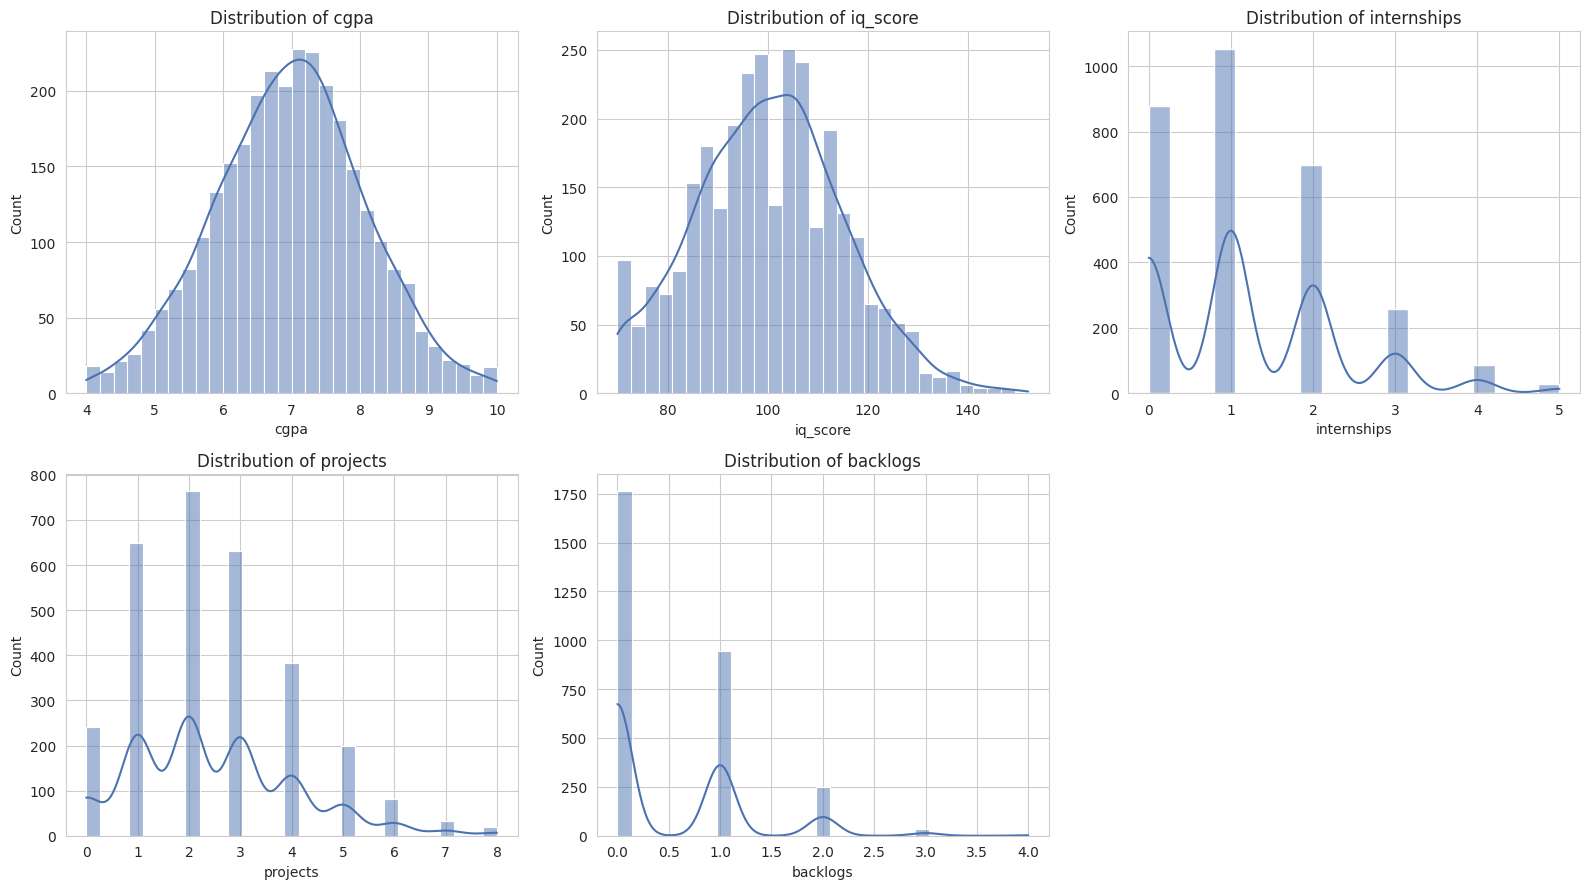

In [11]:
plot_univariate_numeric(df);

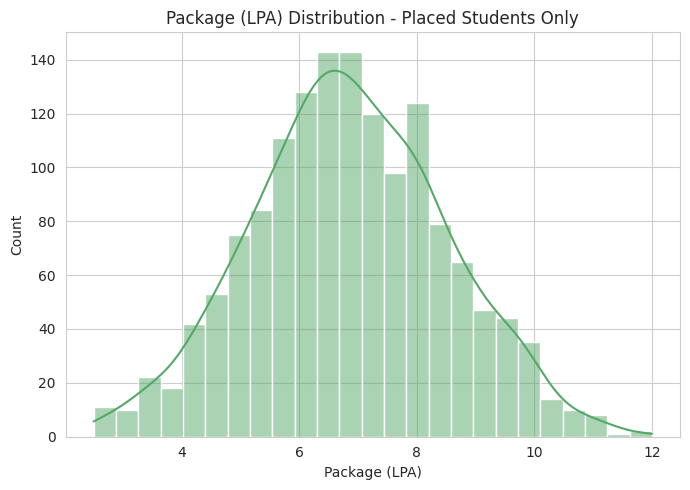

In [12]:
plot_package_distribution(df);

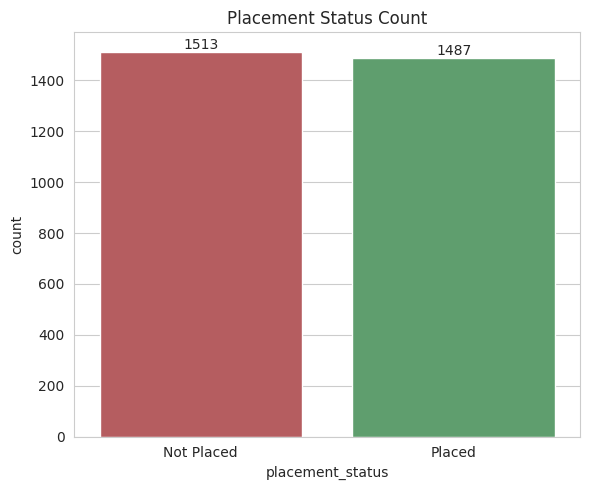

In [13]:
plot_placement_countplot(df);

**Observations:**
- `cgpa` is roughly bell-shaped around ~7, as designed.
- `package_lpa` (placed students only) is right-skewed — most placed students land in the ₹4–9 LPA range, with a smaller number of higher outliers. This is realistic: salary distributions are almost always right-skewed in real placement data, which is one reason tree-based regressors often handle this target well.
- `placement_status` is close to balanced (~50/50), so accuracy alone won't be badly misleading for classification, though we'll still report precision/recall/F1 per the project requirements.


### 4.2 Bivariate Analysis

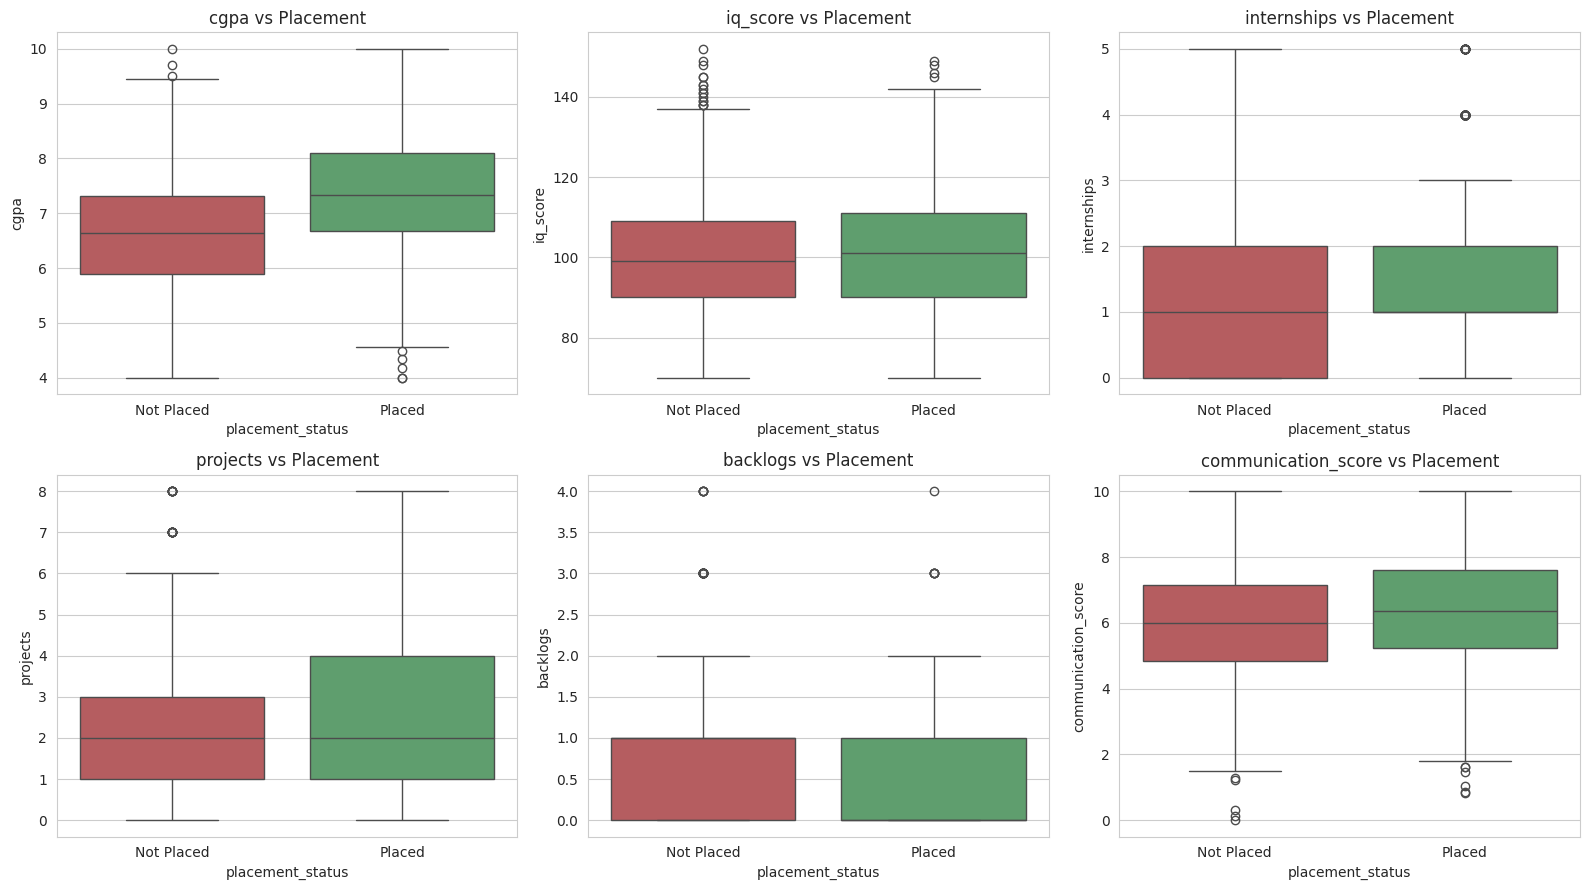

In [14]:
plot_bivariate_box(df);

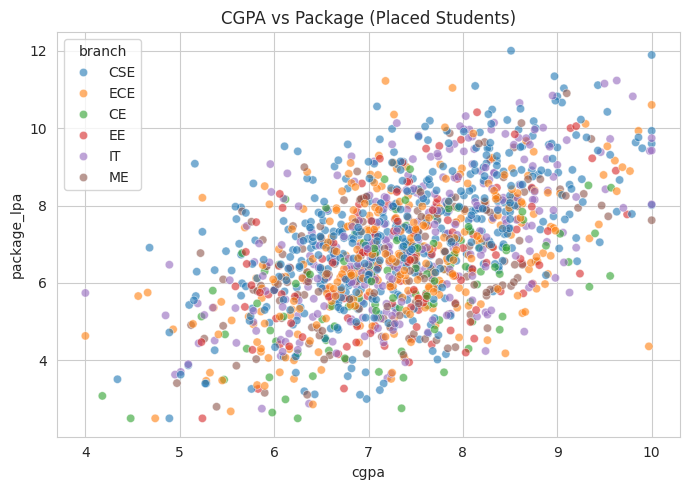

In [15]:
plot_cgpa_vs_package(df);

**Observations:**
- `cgpa`, `technical_skills_score`, `projects`, and `internships` are visibly higher (on median) for `Placed` students than `Not Placed` — consistent with how the dataset was generated, and these will likely be the most useful classification features.
- `iq_score` and `backlogs` show only a small visible shift between the two groups — weaker signal, still worth keeping since even weak-but-real signal helps ensemble models.
- CGPA vs Package shows a clear positive relationship (confirmed by the 0.52 correlation seen in the heatmap below) but with real scatter/noise around it — not a straight line — which mirrors how salary in real placements depends on many factors beyond just CGPA.


### 4.3 Multivariate Analysis — Correlation Heatmap

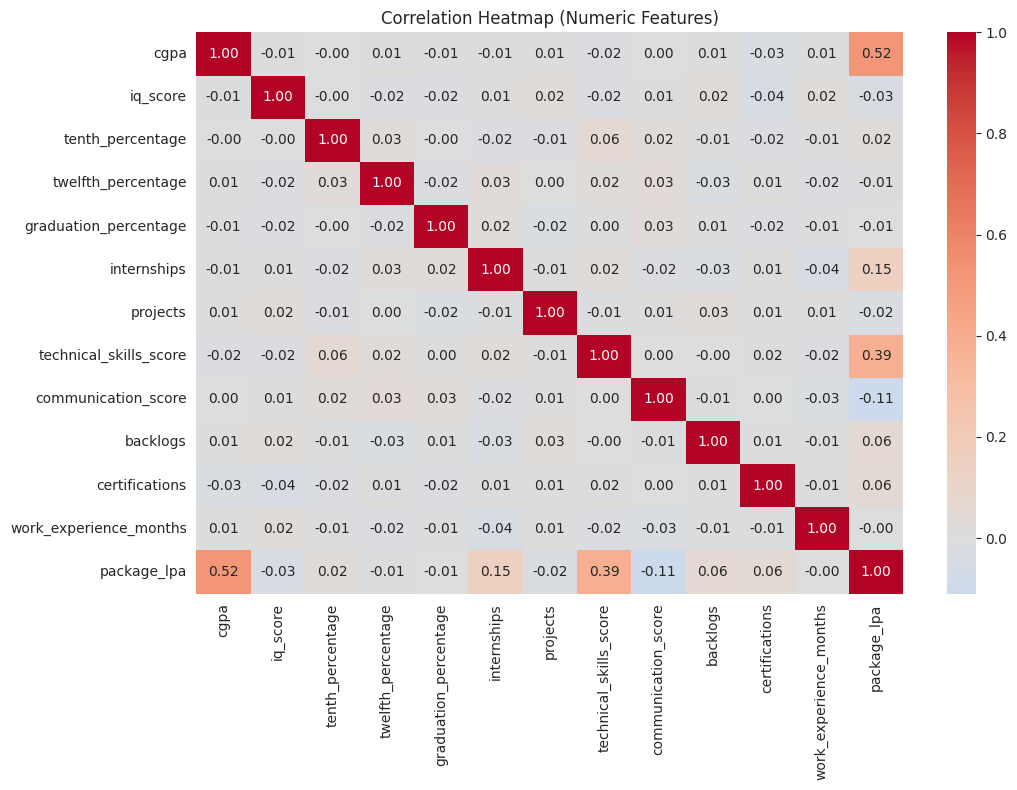

In [16]:
plot_correlation_heatmap(df);

**Observations:**
- `package_lpa` correlates most strongly with `cgpa` (0.52) and `technical_skills_score` (0.39), moderately with `internships` (0.15), and has a small negative correlation with `communication_score` (-0.11) — likely just noise given the weak magnitude, worth re-checking after model training (e.g. via feature importance) rather than concluding communication genuinely hurts salary.
- Crucially, the **predictor features are essentially uncorrelated with each other** (all near 0 off the `package_lpa`/target row/column) — there's no meaningful multicollinearity among CGPA, IQ, internships, projects, skills, communication, backlogs, certifications, or work experience. This means we don't need to drop any features for redundancy, and coefficients in linear models (Ridge/Lasso) will be reasonably interpretable.
- No signs of data leakage in this matrix — no feature is suspiciously perfectly correlated (~1.0) with either target, which would have signaled that a feature is secretly encoding the answer.
